In [1]:
# Test pointwise errors of RectI on a model function 
# RectI is (scipy.interpolate.RectBivariateSpline) wrapped in PyTorch


In [2]:
%reset -f
%run RectI_defs.ipynb


In [3]:

# There are 2 different interpolations
# options = {'kx': 1, 'ky':1, 's':0} # linear
options = {'kx': 3, 'ky':3, 's':0} # cubic spline
# set s > 0 if fitting noisy data

import time

# function for testing the 2D interpolation 
cf1 = 1; cf2 = 0.5
def f_test(x, y):
    x, y = torch.broadcast_tensors(torch.as_tensor(x), torch.as_tensor(y))
    # This is to make it work when x or y is a numpy array or a scalar
    return torch.cos(cf1*(x+y-1))*torch.cos(cf2*(x-y))

# 2D points for testing the 2D interpolation 
nq = 20000
xq = torch.rand(nq, device=device)
yq = torch.rand(nq, device=device)

nx = 128
ny = nx; dx = 1/nx; dy = 1/ny
    
# generate the rectangular grid and interpolation data
x = torch.arange(0, nx+1, device=device)*dx
y = torch.arange(0, ny+1, device=device)*dy
x2d, y2d = torch.meshgrid(x, y, indexing='ij')
u = f_test(x2d, y2d) # interpolation data

start_time = time.perf_counter()
# construct the interpolation function
interp_pt = pt_2d_interpolation(x, y, u, **options)
end_time = time.perf_counter()
elapsed_time = end_time - start_time

uq_pred = interp_pt(xq, yq) # interpolation prediction
uq_true = f_test(xq, yq) # true value
    
err_np = (uq_pred-uq_true).abs().cpu().numpy()
x_np = xq.cpu().numpy()
y_np = yq.cpu().numpy()
err_rms = np.sqrt((err_np**2).mean())

print(f'options = {options}')
print(f'(nx, ny) = ({nx}, {nx}), ellapsed time = {elapsed_time:.4f}s')

print(f'(mean, std, max) error =',
    f'({err_np.mean():.4e}, {err_np.std():.4e}, {err_np.max():.4e})')
err_rms = np.sqrt((err_np**2).mean())
print(f'(RMS error)*(1, nx^2, nx^4) =',
    f'({err_rms:.4e}, {err_rms*nx**2:.4e}, {err_rms*nx**4:.4e})')


options = {'kx': 3, 'ky': 3, 's': 0}
(nx, ny) = (128, 128), ellapsed time = 0.0017s
(mean, std, max) error = (2.7610e-11, 2.3167e-11, 2.4165e-10)
(RMS error)*(1, nx^2, nx^4) = (3.6042e-11, 5.9051e-07, 9.6749e-03)


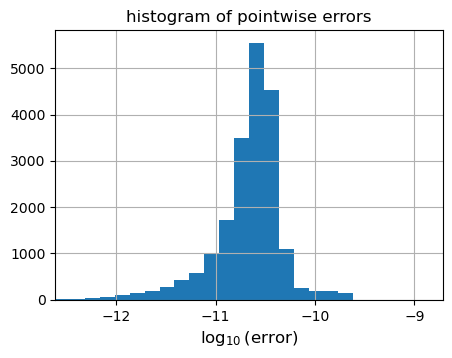

In [4]:
# histogram of pointwise errors 

import matplotlib.pyplot as plt 
from matplotlib.colors import LogNorm

plt.figure(figsize=(5,3.5))
err_log = np.log10(err_np)
bin = np.median(err_log)+np.arange(-2, 2, 0.15)
counts,_,_ = plt.hist(err_log, bin)
plt.xlabel(r'$\log_{10}$(error)', fontsize=12)
plt.grid(True)
plt.xticks(np.arange(-14,-1))
plt.xlim(min(bin), max(bin))
plt.title('histogram of pointwise errors')
plt.show()


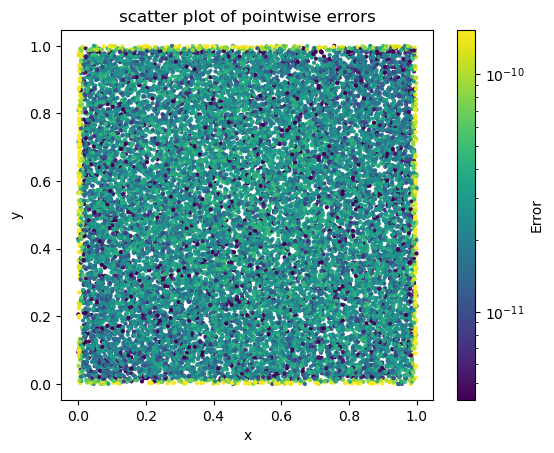

In [5]:
# scatter plot of pointwise errors clipped at 5th pctl and 99th pctl

plt.figure(figsize=(6,4.8))
vmin = np.percentile(err_np, 5)
vmax = np.percentile(err_np, 99)
sc_plt = plt.scatter(x_np, y_np, c=err_np,
    cmap='viridis',
    norm=LogNorm(vmin=vmin, vmax=vmax),
    s = 4)
cbar = plt.colorbar(sc_plt, label='Error')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title('scatter plot of pointwise errors')
plt.show()


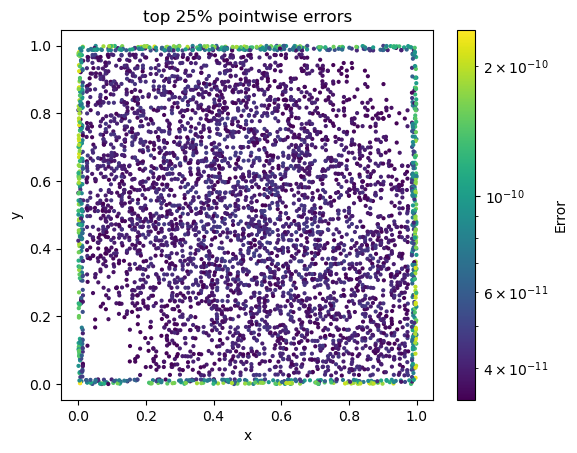

In [6]:
# scatter plot of pointwise errors above 75th pctl
# That is, plotting only the top 25%

import matplotlib.pyplot as plt 
from matplotlib.colors import LogNorm

plt.figure(figsize=(6,4.8))
mask = err_np > np.quantile(err_np, 0.75)
sc_plt = plt.scatter(x_np[mask], y_np[mask], c=err_np[mask],
    cmap='viridis',
    norm=LogNorm(),
    s = 4)
cbar = plt.colorbar(sc_plt, label='Error')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title('top 25% pointwise errors')
plt.show()


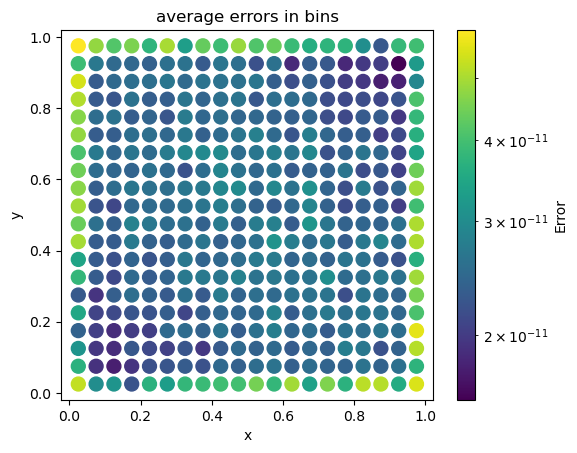

In [7]:

# scatter plot of average errors in bins over a 20x20 array of bins 

import matplotlib.pyplot as plt 
from scipy.stats import binned_statistic_2d

Eavg, xedge, yedge, _ = binned_statistic_2d(x_np, y_np, err_np,
    statistic='mean',
    bins=(20, 20))
xc, yc = np.meshgrid(0.5*(xedge[:-1]+xedge[1:]), 0.5*(yedge[:-1]+yedge[1:]), indexing='ij')

plt.figure(figsize=(6,4.8))
sc_plt = plt.scatter(xc, yc, c=Eavg,
    cmap='viridis',
    norm=LogNorm(),
    s = 100)
cbar = plt.colorbar(sc_plt, label='Error')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title('average errors in bins')
plt.show()


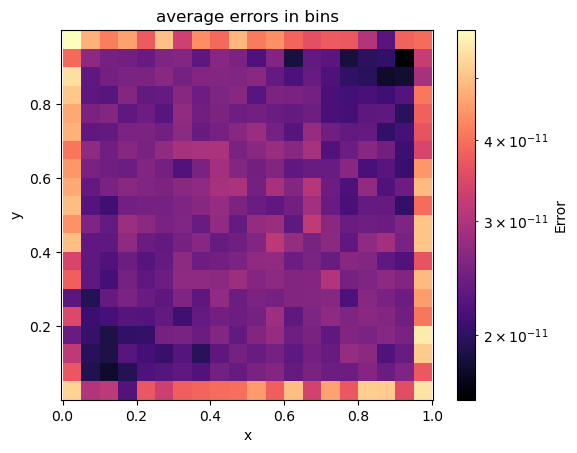

In [8]:

# pcolor plot of average errors in bins over a 20x20 array of bins 

import matplotlib.pyplot as plt 
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d

Eavg, xedge, yedge, _ = binned_statistic_2d(x_np, y_np, err_np,
    statistic='mean',
    bins=(20, 20))

plt.figure(figsize=(6,4.8))
pc_plt = plt.pcolormesh(xedge, yedge, Eavg.T,
    cmap='magma',
    norm=LogNorm(),
    shading='auto')
cbar = plt.colorbar(pc_plt, label='Error')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title('average errors in bins')
plt.show()


In [9]:
# plt.savefig("fig_n1A_wd6_Long.pdf", format="pdf", bbox_inches='tight')